# Coupled climate–photochemistry model of the Archean Earth

This notebook uses [Photochem](https://github.com/Nicholaswogan/photochem) to build a simple, self-consistent model of an Archean Earth (~3 billion years ago): a faint young Sun, an anoxic N₂–CO₂ atmosphere, and volcanic and biological gas fluxes.

Two models are coupled by fixed-point iteration:

| Model | Class | Computes |
|---|---|---|
| Climate | `photochem.clima.AdiabatClimate` | Temperature profile *T(P)* and surface temperature, by radiative–convective equilibrium (RCE), for a given atmospheric composition |
| Photochemistry | `photochem.EvoAtmosphere` | Steady-state composition, for a given *T(P)* and eddy-diffusion profile *K*<sub>zz</sub>(*P*) |

The loop is:

1. Climate model → *T(P)* from an initial guess of the composition.
2. Photochemical model → steady-state composition on that *T(P)*.
3. Climate model → new *T(P)* using the photochemical composition (CH₄, H₂, CO₂, N₂, H₂O).
4. Repeat 2–3 until the surface temperature stops changing.

**Notes on this example**

- The setup is illustrative, not a published Archean reconstruction. Surface fluxes, *K*<sub>zz</sub>, albedo, and humidity are round numbers chosen to be reasonable; change them and see what happens.
- Photochem's built-in time-dependent `evolve-climate` mode (Photochem ≤ 0.8) is not used. It was removed in 0.9, and alternating the two models as done here is the supported approach.
- CO₂ and N₂ surface pressures are fixed, so the coupling acts through H₂O, CH₄ and H₂ (radiatively active, and set by photochemistry). The model has no organic-haze feedback.

## 1. Environment

Photochem is distributed through **conda-forge** (it is not on PyPI). Starting from a bare Miniforge/conda install:

```sh
conda create -n photochem-env -c conda-forge python=3.11 photochem jupyter matplotlib
conda activate photochem-env
jupyter lab
```

or use the `environment.yml` next to this notebook: `conda env create -f environment.yml`.

The next cell checks that everything imports. If you launched Jupyter from a conda environment that lacks Photochem, you can also run `%conda install -c conda-forge photochem` in a cell and restart the kernel.

In [1]:
import os
import time

import numpy as np
import yaml
import matplotlib.pyplot as plt

try:
    import photochem
    from photochem import EvoAtmosphere
    from photochem.clima import AdiabatClimate
    from photochem.utils import (
        stars,
        zahnle_rx_and_thermo_files,
        species_file_for_climate,
        settings_file_for_climate,
    )
except ImportError as err:
    raise ImportError(
        "Photochem is not installed in this kernel. See the install "
        "instructions in the cell above."
    ) from err

print("Photochem version:", photochem.__version__)

# All generated input files go here.
workdir = "archean_coupled"
os.makedirs(workdir, exist_ok=True)

Photochem version: 0.9.1


## 2. Inputs

### Planet and star

Earth's mass and radius, and the Sun's spectrum as it was 3 billion years ago. `stars.solar_spectrum` builds the modern-Sun spectrum from the ATLAS-1 reference spectrum packaged with Photochem (no download needed), extends it to long wavelengths with a blackbody, and rescales it with the Claire et al. (2012) "young Sun" routine, which gives a Sun that is fainter overall (well under today's luminosity) but more UV-active.

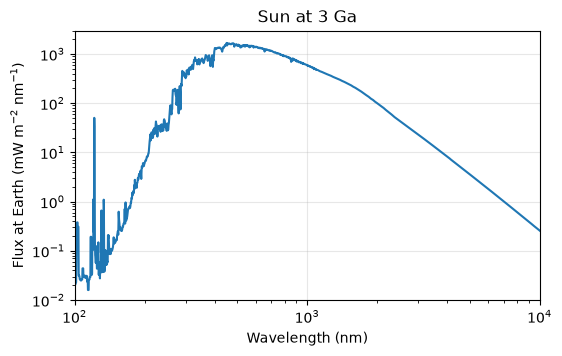

In [2]:
planet_mass = 5.972e27      # g
planet_radius = 6.371e8     # cm
surface_albedo = 0.2
star_age_Gya = 3.0          # Sun's spectrum 3 billion years ago

flux_file = f"{workdir}/sun_3Ga.txt"
wv, flux = stars.solar_spectrum(outputfile=flux_file, age=star_age_Gya)

plt.figure(figsize=(6, 3.5))
plt.loglog(wv, flux)
plt.xlim(100, 1e4); plt.ylim(1e-2, 3e3)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Flux at Earth (mW m$^{-2}$ nm$^{-1}$)")
plt.title("Sun at 3 Ga"); plt.grid(alpha=0.3)
plt.show()

### Chemical network

A subset of Photochem's Zahnle reaction network containing H, He, N, O, C and S chemistry.

In [3]:
mechanism_file = f"{workdir}/mechanism.yaml"
zahnle_rx_and_thermo_files(
    atoms_names=["H", "He", "N", "O", "C", "S"],
    rxns_filename=mechanism_file,
    thermo_filename=None,
    remove_reaction_particles=True,
)

### Boundary conditions (the "Archean" part)

Lower-boundary conditions set the atmosphere's sources and sinks:

- **N₂ = 1 bar, CO₂ = 0.01 bar** fixed partial pressures.
- **No O₂ source.** O₂ and O₃ stay at trace levels, unlike on modern Earth.
- **Volcanic H₂** and **volcanic CO, SO₂, H₂S, OCS** fluxes, and a **biological CH₄** flux. Fluxes are in molecules cm⁻² s⁻¹; `vdep` is a deposition velocity in cm s⁻¹.
- H₂ escapes to space at the diffusion limit.
- Water vapour follows a fixed **relative humidity of 50%** below the cold trap, and condenses above it.

Every gas not listed gets a zero-flux boundary by default.

In [4]:
relative_humidity = 0.5

def bc(name, lower, upper=None):
    return {"name": name, "lower-boundary": lower,
            "upper-boundary": upper or {"type": "veff", "veff": 0.0}}

def surface_source(vdep, flux):
    # flux spread evenly over the lowest layer, plus deposition
    return {"type": "vdep + dist flux", "vdep": vdep, "flux": flux, "height": -1.0}

boundary_conditions = [
    # water: huge nominal pressure -> lower boundary is capped by saturation x RH
    bc("H2O", {"type": "press", "press": 270.0e6}),
    bc("N2",  {"type": "press", "press": 1.0e6}),       # 1 bar (dyn/cm^2)
    bc("CO2", {"type": "press", "press": 0.01e6}),      # 0.01 bar
    bc("O2",  {"type": "flux",  "flux": 0.0}),          # no oxygenic photosynthesis
    bc("H2",  surface_source(0.0, 3.0e10)),             # volcanic
    bc("CH4", {"type": "flux",  "flux": 3.0e10}),       # biological
    bc("CO",  surface_source(1.0e-8, 1.0e9)),
    bc("SO2", surface_source(1.0, 1.0e9)),
    bc("H2S", surface_source(0.015, 1.0e8)),
    bc("OCS", surface_source(0.003, 5.0e7)),
    bc("NO",  surface_source(0.01, 3.0e8)),
    bc("NO2", {"type": "vdep", "vdep": 0.05}),
    bc("NO3", {"type": "vdep", "vdep": 0.05}),
    bc("HNO3", {"type": "vdep", "vdep": 4.0}),
    bc("NH3", surface_source(1.0, 1.5e10)),
    bc("H2SO4", surface_source(1.0, 7.0e8)),
    bc("HCN", surface_source(0.13, 1.7e8)),
    bc("CH3CN", surface_source(0.13, 1.3e8)),
    bc("N2O", surface_source(0.0, 0.0)),
]

photochem_settings = {
    "atmosphere-grid": {"number-of-layers": 100},
    "planet": {
        "planet-mass": planet_mass,
        "planet-radius": planet_radius,
        "surface-albedo": surface_albedo,
        "solar-zenith-angle": 60.0,
        "hydrogen-escape": {"type": "diffusion limited"},
        "water": {"gas-rainout": True, "rainfall-rate": 1, "tropopause-altitude": 1.1e6},
    },
    "particles": [{"name": "H2Oaer", "RH-condensation": relative_humidity}],
    "boundary-conditions": boundary_conditions,
}
settings_file = f"{workdir}/photochem_settings.yaml"
with open(settings_file, "w") as f:
    yaml.safe_dump(photochem_settings, f, sort_keys=False)

### Initialize both models

The climate model tracks the radiatively important gases: H₂O and CO₂ (which can condense), plus N₂, CH₄ and H₂. Everything else in the photochemical network is chemically important but radiatively minor here.

In [5]:
climate_species_file = f"{workdir}/climate_species.yaml"
climate_settings_file = f"{workdir}/climate_settings.yaml"

species_file_for_climate(
    climate_species_file,
    species=["H2O", "CO2", "N2", "CH4", "H2"],
    condensates=["H2O", "CO2"],
)
settings_file_for_climate(
    climate_settings_file, planet_mass, planet_radius, surface_albedo,
)

clim = AdiabatClimate(climate_species_file, climate_settings_file, flux_file)
clim.verbose = False
clim.RH = np.full(len(clim.species_names), relative_humidity)
clim.T_trop = 200.0   # initial guess for the stratospheric temperature (K)

pc = EvoAtmosphere(mechanism_file, settings_file, flux_file)
pc.var.verbose = 0

print("Climate species:", clim.species_names)

Climate species: ['H2', 'H2O', 'CO2', 'CH4', 'N2']


## 3. Coupled simulation

### Step 1: initial climate

With no photochemistry yet, guess trace CH₄ and H₂ and solve for the temperature structure. `surface_temperature` gives a fast approximate solution (adiabat + isothermal stratosphere), which we use as the starting point for a full radiative–convective equilibrium (`RCE`) solve.

In [6]:
def climate_partial_pressures(mixing_ratios, total_pressure_bar):
    # Surface partial pressures (dyn/cm^2), ordered like clim.species_names.
    # H2O is given a large value; the climate model caps it at RH x saturation.
    out = np.full(len(clim.species_names), 1.0e-15)
    for i, name in enumerate(clim.species_names):
        if name == "H2O":
            out[i] = 270.0e6
        elif name in mixing_ratios:
            out[i] = mixing_ratios[name] * total_pressure_bar * 1.0e6
    return out

def solve_climate(P_surf_species, first_guess=False):
    if first_guess:
        clim.surface_temperature(P_surf_species, T_guess=280.0)   # fast approximate solve
    if not clim.RCE(P_surf_species, clim.T_surf, clim.T, clim.convecting_with_below):
        raise RuntimeError("RCE did not converge")

guess = {"N2": 0.98, "CO2": 0.01, "CH4": 1e-5, "H2": 1e-3}
solve_climate(climate_partial_pressures(guess, 1.0), first_guess=True)
T_surf_initial = clim.T_surf
print(f"Initial climate: T_surf = {clim.T_surf:.1f} K, tropopause at {clim.P_trop/1e6:.2f} bar")

def climate_profile():
    # Surface + layer centres, as a strictly decreasing pressure grid
    return np.append(clim.P_surf, clim.P), np.append(clim.T_surf, clim.T)

def eddy_diffusion(P_bar):
    # Kzz (cm^2/s): 1e5 in the troposphere, increasing with altitude above.
    return np.where(P_bar > 0.1, 1.0e5, np.minimum(1.0e5 * (0.1 / P_bar) ** 0.5, 1.0e7))

Initial climate: T_surf = 280.6 K, tropopause at 0.30 bar


### Step 2: give the climate to the photochemical model

`initialize_atmosphere_p` takes a pressure-based *P*–*T*–*K*<sub>zz</sub> profile. With `persistent=True` the profile stays fixed in pressure space while composition evolves, and is updated in place later with `set_press_temp_edd_profile`.

In [7]:
P, T = climate_profile()
pc.initialize_atmosphere_p(
    P, T, eddy_diffusion(P / 1e6),
    mix=None,
    particle_radius={"H2Oaer": np.full(P.size, 1.0e-3)},   # 10 micron cloud drops
    persistent=True,
    tropopause_pressure=float(clim.P_trop),
    target_pressure=P[-1],
)
P_init, T_init = P.copy(), T.copy()

### Step 3: iterate to a self-consistent solution

Each pass runs the photochemistry to steady state, hands the surface CH₄, H₂, CO₂ and N₂ abundances to the climate model, and solves for the new temperature profile. The first photochemical solve starts from scratch and takes a few minutes; later solves restart from the previous state and are much faster.

In [8]:
max_iterations = 10
tolerance_K = 0.1

history = []
start = time.perf_counter()
for iteration in range(max_iterations):
    # photochemistry on the current T(P)
    converged = pc.find_steady_state()
    if not converged:
        print("Warning: photochemistry did not fully converge this iteration")
    atm = pc.mole_fraction_dict()
    total_bar = pc.wrk.surface_pressure

    # climate on the photochemical composition
    mixing = {sp: atm[sp][0] for sp in ["N2", "CO2", "CH4", "H2"]}
    T_previous = clim.T_surf
    solve_climate(climate_partial_pressures(mixing, total_bar))

    history.append({"iteration": iteration, "T_surf": clim.T_surf,
                    "CH4": mixing["CH4"], "H2": mixing["H2"]})
    print(f"iteration {iteration}: T_surf = {clim.T_surf:7.3f} K "
          f"(change {clim.T_surf - T_previous:+.3f} K), "
          f"CH4 = {mixing['CH4']:.2e}, H2 = {mixing['H2']:.2e}, "
          f"elapsed {time.perf_counter() - start:.0f} s")

    if iteration > 0 and abs(clim.T_surf - T_previous) < tolerance_K:
        print("Converged.")
        break

    # pass the new T(P) back to the photochemical model
    pc.destroy_stepper()
    P, T = climate_profile()
    pc.set_press_temp_edd_profile(
        P, T, eddy_diffusion(P / 1e6),
        trop_p=float(clim.P_trop),
        hydro_pressure=True,
        maintain_toa_pressure=True,
        target_pressure=P[-1],
    )
else:
    print("Reached max_iterations without meeting the tolerance.")

iteration 0: T_surf = 284.164 K (change +3.567 K), CH4 = 4.37e-05, H2 = 5.62e-03, elapsed 270 s


iteration 1: T_surf = 284.105 K (change -0.060 K), CH4 = 4.22e-05, H2 = 5.68e-03, elapsed 326 s
Converged.


## 4. Results

In [9]:
atm = pc.mole_fraction_dict()
P_final, T_final = climate_profile()

print(f"Surface temperature: {clim.T_surf:.1f} K ({clim.T_surf - 273.15:.1f} °C)")
print(f"Surface pressure:    {pc.wrk.surface_pressure:.3f} bar")
print(f"Tropopause pressure: {clim.P_trop/1e6:.3f} bar")
print()
print("Surface mixing ratios:")
for sp in ["N2", "CO2", "H2O", "H2", "CH4", "CO", "C2H6", "HCN", "O2", "O3"]:
    print(f"  {sp:5s} {atm[sp][0]:.2e}")

Surface temperature: 284.1 K (11.0 °C)
Surface pressure:    1.060 bar
Tropopause pressure: 0.301 bar

Surface mixing ratios:
  N2    9.79e-01
  CO2   9.79e-03
  H2O   5.50e-03
  H2    5.68e-03
  CH4   4.22e-05
  CO    9.45e-05
  C2H6  1.42e-09
  HCN   4.98e-11
  O2    7.72e-15
  O3    2.85e-21


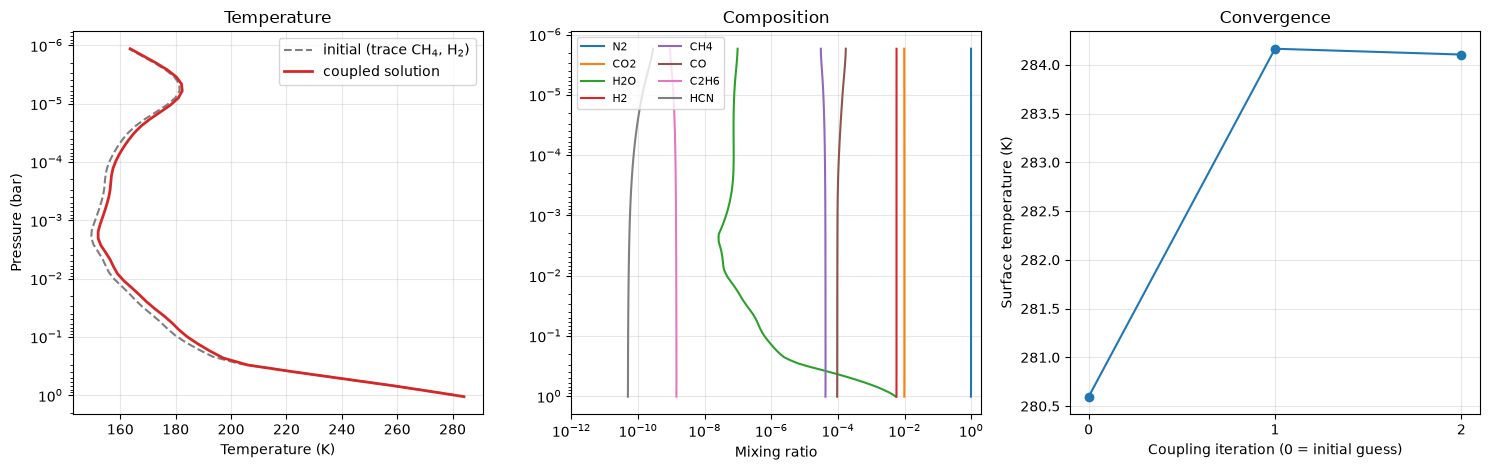

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# Temperature structure
ax = axes[0]
ax.plot(T_init, P_init / 1e6, "--", color="C7", label="initial (trace CH$_4$, H$_2$)")
ax.plot(T_final, P_final / 1e6, color="C3", lw=2, label="coupled solution")
ax.set_yscale("log"); ax.invert_yaxis()
ax.set_xlabel("Temperature (K)"); ax.set_ylabel("Pressure (bar)")
ax.set_title("Temperature"); ax.legend(); ax.grid(alpha=0.3)

# Composition
ax = axes[1]
for sp in ["N2", "CO2", "H2O", "H2", "CH4", "CO", "C2H6", "HCN"]:
    ax.plot(atm[sp], atm["pressure"] / 1e6, label=sp)
ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_yaxis()
ax.set_xlim(1e-12, 2)
ax.set_xlabel("Mixing ratio"); ax.set_title("Composition")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)

# Convergence
ax = axes[2]
ax.plot(range(len(history) + 1), [T_surf_initial] + [h["T_surf"] for h in history], "o-")
ax.ticklabel_format(useOffset=False, axis="y")
ax.set_xlabel("Coupling iteration (0 = initial guess)"); ax.set_ylabel("Surface temperature (K)")
ax.set_title("Convergence"); ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout(); plt.show()

### Diagnostics

Photochem can decompose the budget of any species. Here, what makes and destroys methane at steady state:

In [11]:
budget = pc.production_and_loss("CH4", pc.wrk.usol)
print("Column-integrated CH4 production (molecules cm^-2 s^-1):")
for name, rate in list(zip(budget.production_rx, budget.integrated_production))[:4]:
    print(f"  {name:30s} {rate:.2e}")
print("Column-integrated CH4 loss (molecules cm^-2 s^-1):")
for name, rate in list(zip(budget.loss_rx, budget.integrated_loss))[:4]:
    print(f"  {name:30s} {rate:.2e}")

surface_fluxes, top_fluxes = pc.gas_fluxes()
print(f"\nH2 escape flux at top of atmosphere: {top_fluxes['H2']:.2e} molecules cm^-2 s^-1")

Column-integrated CH4 production (molecules cm^-2 s^-1):
  lower boundary flux            3.00e+10
  vertical transport             3.00e+10
  CH3 + HCO => CH4 + CO          1.55e+09
  CH3 + H + M => CH4 + M         4.66e+08
Column-integrated CH4 loss (molecules cm^-2 s^-1):
  vertical transport             3.00e+10
  CH4 + hv => 1CH2 + H2          1.23e+10
  CH4 + hv => CH3 + H            1.11e+10
  CH4 + hv => CH2 + H + H        2.51e+09

H2 escape flux at top of atmosphere: 1.46e+11 molecules cm^-2 s^-1


## 5. Next steps

- **Vary the forcing.** Change `star_age_Gya`, the CO₂ partial pressure (`"CO2"` boundary condition), or the CH₄ flux and re-run from section 3. Note that real atmospheres with high CH₄/CO₂ ratios form organic haze, which this model does not include, so be cautious with large CH₄ fluxes.
- **Change the planet.** `surface_albedo` is set once in section 2 and used by both models; re-run from section 2 if you change it.
- **Go further.** Photochem's documentation has tutorials on [rocky-planet photochemistry](https://nicholaswogan.github.io/photochem/tutorials/) and climate, and on the API of each model.

*Citation:* if you use Photochem in a publication, please cite [Wogan et al. (2025)](https://doi.org/10.3847/PSJ/ae0e1c).